###Loading the Dataset


In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Fetching the dataset
housing_data = fetch_california_housing(as_frame=True)

# Combining features and target into a single DataFrame
df = pd.concat([housing_data.data, housing_data.target.rename('MedHouseVal')], axis=1)

# Displaying the first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


###Exploratory Data Analysis (EDA)

In [2]:
# Check the shape (rows, columns)
print(f"Dataset Shape: {df.shape}\n")

# View data types and see if there are any missing values
df.info()

Dataset Shape: (20640, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
# Summary statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
# Count missing values per column
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


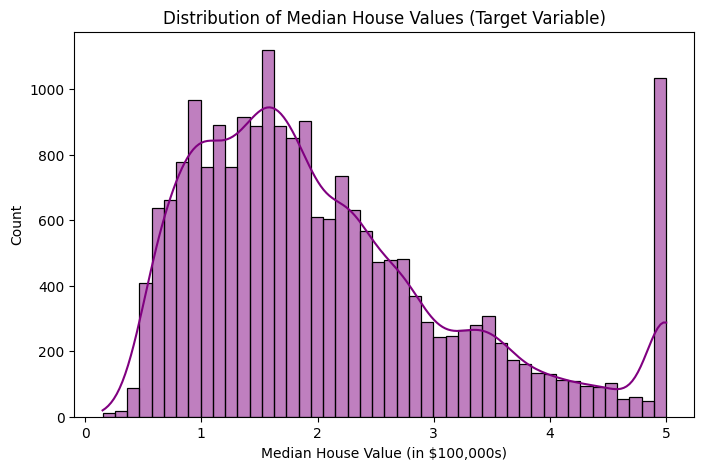

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], kde=True, color='purple')
plt.title("Distribution of Median House Values (Target Variable)")
plt.xlabel("Median House Value (in $100,000s)")
plt.ylabel("Count")
plt.show()

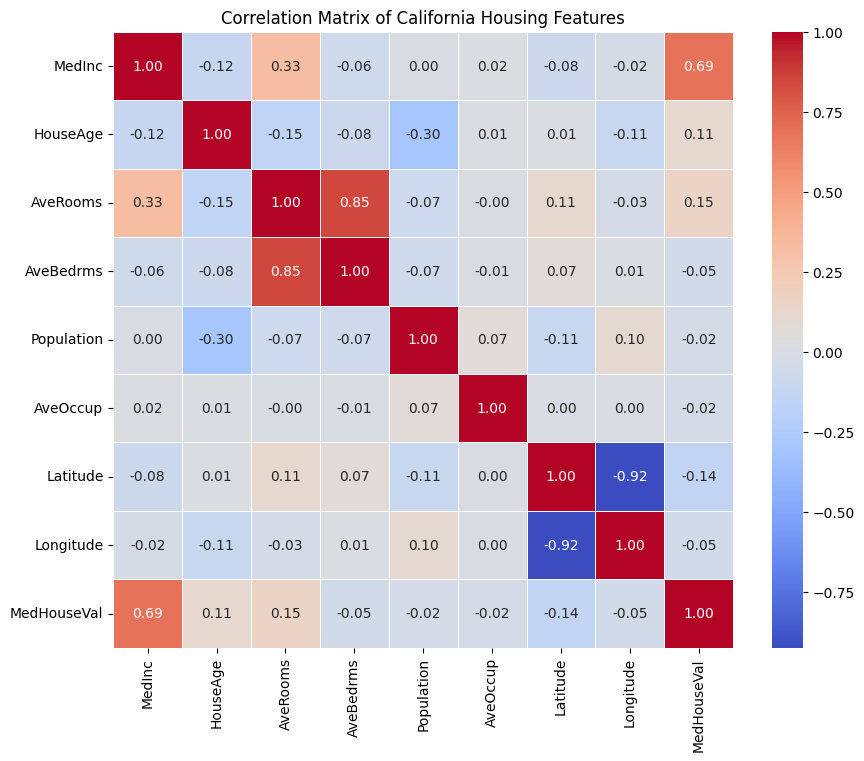

In [6]:
plt.figure(figsize=(10, 8))

# Calculate correlation and plot it as a heatmap
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of California Housing Features")
plt.show()

###Feature Selection and Data splitting

In [7]:
# 1. Separate features (X) and target variable (y)
X = df.drop(columns='MedHouseVal')  # All columns except the target
y = df['MedHouseVal']               # Only the target column

# 2. Split into 80% training and 20% testing data
# We set random_state=42 to ensure we get the exact same split every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Print the shapes to confirm the split worked
print(f"Full Feature Dataset Shape: {X.shape}")
print(f"Training Features Shape   : {X_train.shape} (80%)")
print(f"Testing Features Shape    : {X_test.shape} (20%)")

Full Feature Dataset Shape: (20640, 8)
Training Features Shape   : (16512, 8) (80%)
Testing Features Shape    : (4128, 8) (20%)


###Train and Evaluate the Linear Regression Model


In [8]:
# 1. Initialize the Linear Regression Model
model = LinearRegression()

# 2. Train the model using the training data
model.fit(X_train, y_train)

# 3. Use the trained model to predict housing prices on the test data
y_pred = model.predict(X_test)

# 4. Calculate the Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Manual sqrt as squared=False is deprecated
r2 = r2_score(y_test, y_pred)

# 5. Display the performance metrics
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE)      : {mae:.3f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.3f}")
print(f"R² Score (Coefficient of Det.) : {r2:.3f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE)      : 0.533
Root Mean Squared Error (RMSE) : 0.746
R² Score (Coefficient of Det.) : 0.576


###Visualize the results

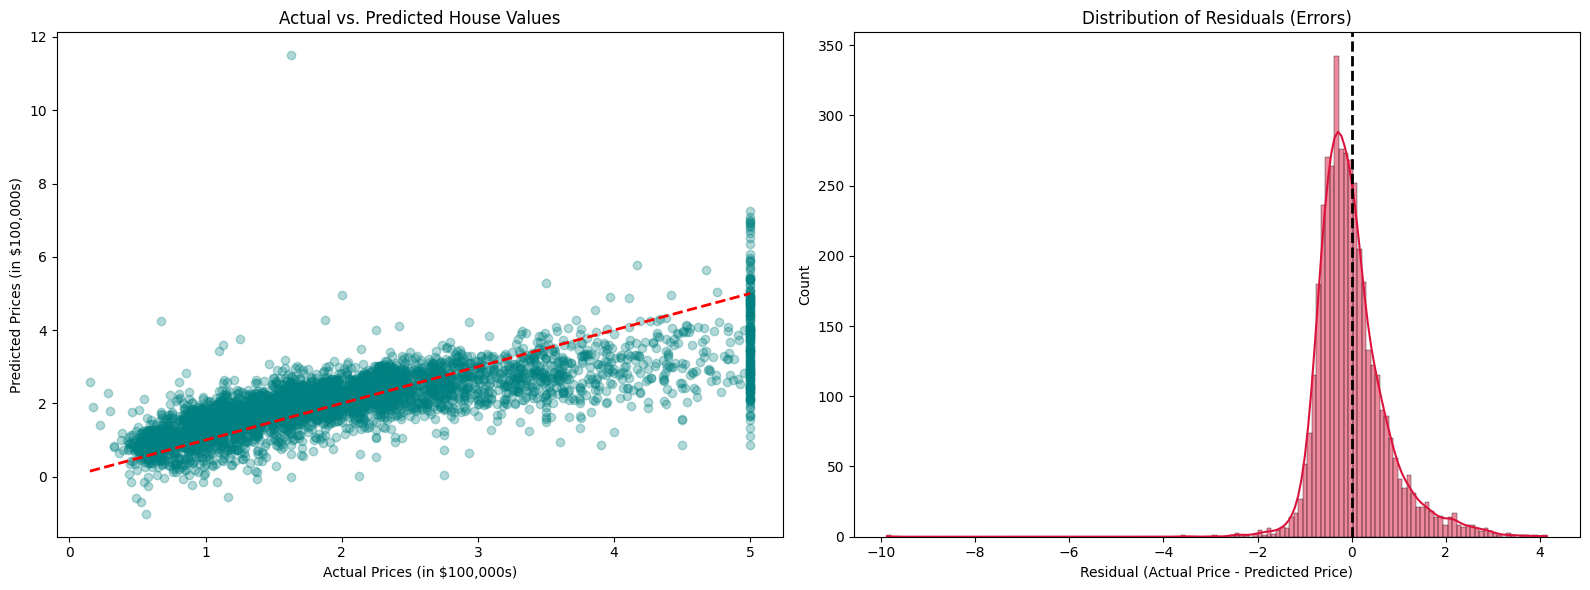

In [9]:
# Set up a side-by-side plotting area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Actual vs. Predicted Scatter Plot ---
ax1.scatter(y_test, y_pred, alpha=0.3, color='teal')
# Draw a perfect diagonal line for reference (where Actual == Predicted)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
ax1.set_xlabel("Actual Prices (in $100,000s)")
ax1.set_ylabel("Predicted Prices (in $100,000s)")
ax1.set_title("Actual vs. Predicted House Values")

# --- Plot 2: Residuals Distribution Plot ---
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='crimson', ax=ax2)
ax2.axvline(0, color='black', linestyle='--', lw=2) # Line at 0 error
ax2.set_xlabel("Residual (Actual Price - Predicted Price)")
ax2.set_title("Distribution of Residuals (Errors)")

plt.tight_layout()
plt.show()